# Solving the Steady-State 2D RTE using a Variational PINN (VPINN)

In this notebook, we solve the steady-state 2D Radiative Transfer Equation (RTE) in a participating square medium using a **Variational-PINN** approach. 

### Case 2 (2D)
We focus on a 2D space + 3D direction test case with the following configuration:
* **Geometry:** $0 \le x \le L_x$ and $0 \le y \le L_y$ with $L_x = L_y = 1.0\text{ m}$ (Square medium).
* **Directions:** Direction of propagation $\vec{s}$ defined by spherical angles $(\theta, \phi)$, with directional cosines:
  * $\mu = \sin\theta \cos\phi$ (x-axis)
  * $\eta = \sin\theta \sin\phi$ (y-axis)
* **Equation (2D RTE):**
  $$\mu \frac{\partial I}{\partial x} + \eta \frac{\partial I}{\partial y} + (\kappa + \sigma) I(x, y, \mu, \eta) = \frac{\sigma}{4\pi} G(x, y)$$
  where $G(x, y) = \int_{0}^{2\pi} \int_{0}^{\pi} I(x, y, \theta', \phi') \sin\theta' d\theta' d\phi'$.
* **Physical Properties:**
  * Scattering coefficient: $\sigma = 1.0\text{ m}^{-1}$ (Isotropic scattering).
  * Absorption coefficient: $\kappa = 0\text{ m}^{-1}$ (Non-absorbing scattering medium).
* **Boundary Conditions (BC) on incoming directions:**
  * Top boundary ($y = 1$, for $\eta < 0$): $I(x, 1, \mu, \eta) = 1.0$ (Diffuse radiation).
  * Bottom boundary ($y = 0$, for $\eta > 0$): $I(x, 0, \mu, \eta) = 0.0$
  * Left boundary ($x = 0$, for $\mu > 0$): $I(0, y, \mu, \eta) = 0.0$
  * Right boundary ($x = 1$, for $\mu < 0$): $I(1, y, \mu, \eta) = 0.0$

### What changes compared to the strong-form PINN
Instead of forcing the residual $R$ to vanish **at collocation points**, we force its **projections onto a basis of spatial test functions** to vanish. The test basis is the orthonormal cosine family (non-vanishing on the boundary):
$$v_{km}(x, y) = \varphi_k(x)\,\varphi_m(y), \qquad \varphi_0 = 1,\ \varphi_k = \sqrt{2}\cos(k\pi t), \qquad k, m = 0, \dots, K-1$$

Integration by parts moves the interior derivatives onto the test functions (analytical — **no autograd** in the physics loss) and produces a **boundary flux term** in which the inflow data is imposed weakly (upwind flux, as in discontinuous-Galerkin methods). For each direction $(\mu_q, \eta_q)$:

$$\mathcal{R}_{km,q} = \oint_{\partial\Omega} (\vec s_q \cdot \vec n)\, \hat I\, v_{km}\, ds \;-\; \iint I\, \big(\mu_q \partial_x v_{km} + \eta_q \partial_y v_{km}\big) \;+\; \iint \big((\kappa+\sigma) I - \tfrac{\sigma}{4\pi} G\big)\, v_{km}$$

with the **upwind rule**: $\hat I = g$ (the prescribed boundary data: 1 on the top wall, 0 elsewhere) on the inflow parts of the boundary ($\vec s_q \cdot \vec n < 0$), and $\hat I = I$ (the network) on the outflow parts. Angles stay in collocation: each epoch draws a batch of $Q$ directions and imposes the $K^2$ weak residuals for each.

$$\mathcal{L} = \lambda_{bc}\, \mathcal{L}_{BC} + \frac{1}{K^2 Q} \sum_{k,m,q} \mathcal{R}_{km,q}^2$$

> **Why the boundary term is essential.** A first version used sine test functions vanishing on the whole boundary, discarding the boundary bracket of the integration by parts. For a *first-order transport* equation this decouples the physics from the inflow data: the trivial field $I \equiv 0$ then zeroes the weak loss exactly, and the network satisfied the separate BC penalty with an infinitely thin layer at $y=1$, invisible to both losses (final loss $1.3\times10^{-5}$, solution 100% wrong — caught by the DOM reference and the exact anchor $G(0.5,0.5)=\pi$). 

**Caveats**: the weak loss only controls the spatial modes $< K$ of the residual — validation is always done against the DOM solver and the exact anchor $G(0.5, 0.5) = \pi$.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

## 1. PINN Architecture Definition
Definition of the standard Neural Network (Multi-Layer Perceptron) to approximate the intensity $I(x, y, \mu, \eta)$.

In [2]:
class PinnRFEEq2D(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=4):
        super().__init__()
        layers = []
        layers.append(nn.Linear(4, hidden_dim))
        layers.append(nn.Tanh())
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 2. Angular Quadrature (for $G$)
Setting up a tensor product of Gauss-Legendre quadratures for $\xi = \cos\theta \in [-1, 1]$ and $\phi \in [0, 2\pi]$ to perform solid angle integration.

In [3]:
def init_quadrature(N_theta=8, N_phi=16, device='cpu'):
    nodes_xi, weights_xi = np.polynomial.legendre.leggauss(N_theta)
    nodes_xi = 0.5 * (nodes_xi + 1.0)

   
    nodes_phi = (np.arange(N_phi) + 0.5) * 2.0 * np.pi / N_phi
    weights_phi = np.full(N_phi, 2.0 * np.pi / N_phi)

    quad_mu_list = []
    quad_eta_list = []
    quad_w_list = []

    for i in range(N_theta):
        for j in range(N_phi):
            xi = nodes_xi[i]
            phi = nodes_phi[j]
            w = weights_xi[i] * weights_phi[j]
            
            mu = np.sqrt(1.0 - xi**2) * np.cos(phi)
            eta = np.sqrt(1.0 - xi**2) * np.sin(phi)
            
            quad_mu_list.append(mu)
            quad_eta_list.append(eta)
            quad_w_list.append(w)

    quad_mu = torch.tensor(quad_mu_list, dtype=torch.float32).view(-1, 1).to(device)
    quad_eta = torch.tensor(quad_eta_list, dtype=torch.float32).view(-1, 1).to(device)
    quad_w = torch.tensor(quad_w_list, dtype=torch.float32).view(-1, 1).to(device)
    return quad_mu, quad_eta, quad_w

## 3. Test Basis, Spatial Quadrature and Edge Traces
Test basis $v_{km}(x,y) = \varphi_k(x)\varphi_m(y)$ with $\varphi_0 = 1$, $\varphi_k = \sqrt{2}\cos(k\pi t)$ — orthonormal on $[0,1]^2$ and **non-vanishing on the boundary** (required by the upwind flux term). Gauss-Legendre quadrature $n_g \times n_g$ inside, $n_g$ points per edge.

Precomputed matrices (quadrature weights already folded in):
* `WV @ f` $\approx \big[\iint f\, v_{km}\big]$, and `WVx`, `WVy` carry $\partial_x v$, $\partial_y v$ (analytical);
* for each of the 4 edges: `WB @ f` $\approx \big[\int_{\text{edge}} f\, v_{km}\, ds\big]$, plus the outward normal $(n_x, n_y)$ and the inflow data $g$ (1 on the hot top wall, 0 elsewhere).

In [4]:
def init_base_test(K=8, ng=32, device='cpu'):
    nodes, w = np.polynomial.legendre.leggauss(ng)
    xg = 0.5 * (nodes + 1.0)
    wg = 0.5 * w
    X, Y = np.meshgrid(xg, xg, indexing='ij')
    xj = X.ravel()
    yj = Y.ravel()
    wj = np.outer(wg, wg).ravel()

    # base 1D orthonormee NON nulle au bord : phi_0 = 1, phi_k = sqrt(2) cos(k pi t)
    ks = np.arange(K)

    def phi(t):
        vals = np.sqrt(2.0) * np.cos(np.pi * np.outer(ks, t))
        vals[0, :] = 1.0
        return vals

    def dphi(t):
        # la ligne k=0 est nulle automatiquement (facteur ks)
        return -np.sqrt(2.0) * np.pi * ks[:, None] * np.sin(np.pi * np.outer(ks, t))

    px, dpx = phi(xj), dphi(xj)
    py, dpy = phi(yj), dphi(yj)

    V  = (px[:, None, :] * py[None, :, :]).reshape(K * K, -1)
    Vx = (dpx[:, None, :] * py[None, :, :]).reshape(K * K, -1)
    Vy = (px[:, None, :] * dpy[None, :, :]).reshape(K * K, -1)

    to_t = lambda a: torch.tensor(a, dtype=torch.float32).to(device)

    # aretes : quadrature 1D, traces de la base (ponderees par we), normale
    # sortante (nx, ny), donnee entrante g (1 sur la paroi chaude y=1, 0 ailleurs)
    se, we = xg, wg
    zero, un = np.zeros(ng), np.ones(ng)
    pse, p0, p1 = phi(se), phi(zero), phi(un)

    aretes = []
    for xa, ya, pa_x, pa_y, nx, ny, g in [
        (se,   zero, pse, p0,  0.0, -1.0, 0.0),   # bas    (y=0)
        (se,   un,   pse, p1,  0.0,  1.0, 1.0),   # haut   (y=1) : paroi chaude
        (zero, se,   p0,  pse, -1.0, 0.0, 0.0),   # gauche (x=0)
        (un,   se,   p1,  pse,  1.0, 0.0, 0.0),   # droite (x=1)
    ]:
        WB = (pa_x[:, None, :] * pa_y[None, :, :]).reshape(K * K, -1) * we
        aretes.append((to_t(xa).view(-1, 1), to_t(ya).view(-1, 1), to_t(WB), nx, ny, g))

    return (to_t(xj).view(-1, 1), to_t(yj).view(-1, 1),
            to_t(V * wj), to_t(Vx * wj), to_t(Vy * wj), aretes)

## 4. Sampling
Directions: uniform draws on the unit sphere (a mini-batch of $Q$ directions, resampled at every epoch). Boundary points: identical to the strong-form notebook (incoming directions only, on the four edges).

In [5]:
def tirer_directions(Q):
    xi = torch.rand(Q, 1) * 2.0 - 1.0
    phi = torch.rand(Q, 1) * 2.0 * np.pi
    mu = torch.sqrt(1.0 - xi**2) * torch.cos(phi)
    eta = torch.sqrt(1.0 - xi**2) * torch.sin(phi)
    return mu.float(), eta.float()

def generer_points_bords(n_bords):
    n_edge = n_bords // 4

    # Left edge: x = 0, y in [0,1], mu > 0 (phi in [-pi/2, pi/2])
    x_left = torch.zeros(n_edge, 1)
    y_left = torch.rand(n_edge, 1)
    xi_left = torch.rand(n_edge, 1) * 2.0 - 1.0
    phi_left = (torch.rand(n_edge, 1) - 0.5) * np.pi
    mu_left = torch.sqrt(1.0 - xi_left**2) * torch.cos(phi_left)
    eta_left = torch.sqrt(1.0 - xi_left**2) * torch.sin(phi_left)

    # Right edge: x = 1, y in [0,1], mu < 0 (phi in [pi/2, 3*pi/2])
    x_right = torch.ones(n_edge, 1)
    y_right = torch.rand(n_edge, 1)
    xi_right = torch.rand(n_edge, 1) * 2.0 - 1.0
    phi_right = torch.rand(n_edge, 1) * np.pi + 0.5 * np.pi
    mu_right = torch.sqrt(1.0 - xi_right**2) * torch.cos(phi_right)
    eta_right = torch.sqrt(1.0 - xi_right**2) * torch.sin(phi_right)

    # Bottom edge: x in [0,1], y = 0, eta > 0 (phi in [0, pi])
    x_bottom = torch.rand(n_edge, 1)
    y_bottom = torch.zeros(n_edge, 1)
    xi_bottom = torch.rand(n_edge, 1) * 2.0 - 1.0
    phi_bottom = torch.rand(n_edge, 1) * np.pi
    mu_bottom = torch.sqrt(1.0 - xi_bottom**2) * torch.cos(phi_bottom)
    eta_bottom = torch.sqrt(1.0 - xi_bottom**2) * torch.sin(phi_bottom)

    # Top edge: x in [0,1], y = 1, eta < 0 (phi in [pi, 2*pi])
    x_top = torch.rand(n_edge, 1)
    y_top = torch.ones(n_edge, 1)
    xi_top = torch.rand(n_edge, 1) * 2.0 - 1.0
    phi_top = torch.rand(n_edge, 1) * np.pi + np.pi
    mu_top = torch.sqrt(1.0 - xi_top**2) * torch.cos(phi_top)
    eta_top = torch.sqrt(1.0 - xi_top**2) * torch.sin(phi_top)

    return (
        x_left.float(), y_left.float(), mu_left.float(), eta_left.float(),
        x_right.float(), y_right.float(), mu_right.float(), eta_right.float(),
        x_bottom.float(), y_bottom.float(), mu_bottom.float(), eta_bottom.float(),
        x_top.float(), y_top.float(), mu_top.float(), eta_top.float(),
    )

## 5. Loss Functions
* `calc_bc_loss`: identical to the strong-form version — kept as a helper (the upwind flux already carries the BC data into the physics).
* `calc_vpinn_loss`: the weak residuals = interior terms (integrated by parts) **+ the upwind boundary flux term**, edge by edge: $\hat I = g$ where the direction enters ($\vec s \cdot \vec n < 0$), $\hat I = I$ where it exits. Still **no `torch.autograd.grad`** — the network is only evaluated (inside and on the edges); the derivatives live in `WVx`, `WVy`.

In [6]:
def calc_bc_loss(model,
                 x_l, y_l, mu_l, eta_l,
                 x_r, y_r, mu_r, eta_r,
                 x_b, y_b, mu_b, eta_b,
                 x_t, y_t, mu_t, eta_t):

    pred_l = model(torch.cat([x_l, y_l, mu_l, eta_l], dim=1))
    pred_r = model(torch.cat([x_r, y_r, mu_r, eta_r], dim=1))
    pred_b = model(torch.cat([x_b, y_b, mu_b, eta_b], dim=1))
    pred_t = model(torch.cat([x_t, y_t, mu_t, eta_t], dim=1))

    loss_l = torch.mean((pred_l - 0.0) ** 2)
    loss_r = torch.mean((pred_r - 0.0) ** 2)
    loss_b = torch.mean((pred_b - 0.0) ** 2)
    loss_t = torch.mean((pred_t - 1.0) ** 2)

    return loss_l + loss_r + loss_b + 5.0 * loss_t

def integrer_G(model, x_t, y_t, quad_mu, quad_eta, quad_w):
    N = x_t.shape[0]
    N_q = quad_mu.shape[0]
    x_expanded = x_t.repeat(1, N_q)
    y_expanded = y_t.repeat(1, N_q)
    mu_expanded = quad_mu.t().repeat(N, 1)
    eta_expanded = quad_eta.t().repeat(N, 1)
    inputs_quad = torch.stack([x_expanded, y_expanded, mu_expanded, eta_expanded], dim=2).view(-1, 4)
    I_quad = model(inputs_quad).view(N, N_q)
    return torch.sum(I_quad * quad_w.t(), dim=1, keepdim=True)

def calc_vpinn_loss(model, mu_q, eta_q, xj_t, yj_t, WV, WVx, WVy, aretes,
                    quad_mu, quad_eta, quad_w, kappa=0.0, sigma=1.0):
    J = xj_t.shape[0]
    Q = mu_q.shape[0]

    G = integrer_G(model, xj_t, yj_t, quad_mu, quad_eta, quad_w)   # (J, 1)

    inp = torch.cat([
        xj_t.repeat(Q, 1),
        yj_t.repeat(Q, 1),
        mu_q.repeat_interleave(J, dim=0),
        eta_q.repeat_interleave(J, dim=0),
    ], dim=1)
    I = model(inp).view(Q, J).t()                                  # (J, Q)

    S = (kappa + sigma) * I - (sigma / (4.0 * np.pi)) * G          # (J, Q)

    # termes interieurs (integres par parties)
    R = -(WVx @ I) * mu_q.t() - (WVy @ I) * eta_q.t() + (WV @ S)   # (K^2, Q)

    # terme de bord upwind : + somme sur les aretes de (s.n) <I_hat, v>_arete
    # I_hat = donnee g sur les aretes entrantes (s.n < 0), I du reseau sinon
    for x_a, y_a, WB, nx, ny, g in aretes:
        na = x_a.shape[0]
        inp_a = torch.cat([
            x_a.repeat(Q, 1),
            y_a.repeat(Q, 1),
            mu_q.repeat_interleave(na, dim=0),
            eta_q.repeat_interleave(na, dim=0),
        ], dim=1)
        I_a = model(inp_a).view(Q, na).t()                         # (na, Q)

        sn = nx * mu_q.t() + ny * eta_q.t()                        # (1, Q)
        entrant = (sn < 0).expand(na, Q)
        I_hat = torch.where(entrant, torch.full_like(I_a, g), I_a)

        R = R + (WB @ I_hat) * sn                                  # (K^2, Q)

    return torch.mean(R ** 2)

## 6. Initialization
$K = 8$ modes per axis (64 test functions), $32 \times 32$ spatial quadrature, ng = 32, $Q = 32$ directions per epoch.

In [7]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

quad_mu, quad_eta, quad_w = init_quadrature(N_theta=16, N_phi=32, device=device)

K = 8
ng = 32
Q = 32
lambda_bc = 10.0
n_bords = 4000
kappa = 0.0
sigma = 1.0

xj_t, yj_t, WV, WVx, WVy, aretes = init_base_test(K=K, ng=ng, device=device)

(
    x_l, y_l, mu_l, eta_l,
    x_r, y_r, mu_r, eta_r,
    x_b, y_b, mu_b, eta_b,
    x_t, y_t, mu_t, eta_t
) = generer_points_bords(n_bords)

x_l, y_l, mu_l, eta_l = x_l.to(device), y_l.to(device), mu_l.to(device), eta_l.to(device)
x_r, y_r, mu_r, eta_r = x_r.to(device), y_r.to(device), mu_r.to(device), eta_r.to(device)
x_b, y_b, mu_b, eta_b = x_b.to(device), y_b.to(device), mu_b.to(device), eta_b.to(device)
x_t, y_t, mu_t, eta_t = x_t.to(device), y_t.to(device), mu_t.to(device), eta_t.to(device)

modele = PinnRFEEq2D(hidden_dim=64, num_layers=4).to(device)

Using device: cuda


## 7. Model Training (Adam)
The $Q$ directions are resampled at every epoch (progressive coverage of the sphere).

In [8]:
optimizer = optim.Adam(modele.parameters(), lr=2e-3)
epochs = 2000

for epoch in range(epochs):
    optimizer.zero_grad()
    mu_q, eta_q = tirer_directions(Q)
    mu_q, eta_q = mu_q.to(device), eta_q.to(device)

    loss_bc = calc_bc_loss(modele,
                           x_l, y_l, mu_l, eta_l,
                           x_r, y_r, mu_r, eta_r,
                           x_b, y_b, mu_b, eta_b,
                           x_t, y_t, mu_t, eta_t)
    loss_faible = calc_vpinn_loss(modele, mu_q, eta_q, xj_t, yj_t, WV, WVx, WVy, aretes,
                                  quad_mu, quad_eta, quad_w, kappa, sigma)
    loss_totale = lambda_bc * loss_bc + loss_faible
    loss_totale.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoque {epoch:04d} | "
              f"Loss totale: {loss_totale.item():.2e} | "
              f"Faible: {loss_faible.item():.2e} | "
              f"BC: {loss_bc.item():.2e}")

Epoque 0000 | Loss totale: 4.56e+01 | Faible: 1.88e-02 | BC: 4.56e+00
Epoque 0100 | Loss totale: 3.54e+00 | Faible: 1.31e-02 | BC: 3.53e-01
Epoque 0200 | Loss totale: 1.51e+00 | Faible: 7.80e-03 | BC: 1.50e-01
Epoque 0300 | Loss totale: 6.65e-01 | Faible: 1.42e-02 | BC: 6.51e-02
Epoque 0400 | Loss totale: 4.13e-01 | Faible: 2.06e-02 | BC: 3.93e-02
Epoque 0500 | Loss totale: 3.64e-01 | Faible: 1.36e-02 | BC: 3.50e-02
Epoque 0600 | Loss totale: 2.66e-01 | Faible: 3.62e-02 | BC: 2.30e-02
Epoque 0700 | Loss totale: 2.32e-01 | Faible: 2.51e-02 | BC: 2.07e-02
Epoque 0800 | Loss totale: 1.83e-01 | Faible: 9.21e-03 | BC: 1.73e-02
Epoque 0900 | Loss totale: 2.21e-01 | Faible: 3.40e-02 | BC: 1.87e-02
Epoque 1000 | Loss totale: 3.38e-01 | Faible: 5.31e-02 | BC: 2.85e-02
Epoque 1100 | Loss totale: 1.42e-01 | Faible: 2.54e-02 | BC: 1.16e-02
Epoque 1200 | Loss totale: 1.43e-01 | Faible: 3.34e-02 | BC: 1.09e-02
Epoque 1300 | Loss totale: 1.19e-01 | Faible: 2.93e-02 | BC: 8.95e-03
Epoque 1400 | Loss t

## 8. Model Training (L-BFGS)
L-BFGS requires a **deterministic** loss: a larger batch of directions ($Q = 64$) is drawn once and kept fixed for the whole phase.

In [9]:
torch.manual_seed(0)
mu_q_fix, eta_q_fix = tirer_directions(64)
mu_q_fix, eta_q_fix = mu_q_fix.to(device), eta_q_fix.to(device)

def closure():
    optimizer_lbfgs.zero_grad()
    loss_bc = calc_bc_loss(modele,
                           x_l, y_l, mu_l, eta_l,
                           x_r, y_r, mu_r, eta_r,
                           x_b, y_b, mu_b, eta_b,
                           x_t, y_t, mu_t, eta_t)
    loss_faible = calc_vpinn_loss(modele, mu_q_fix, eta_q_fix, xj_t, yj_t, WV, WVx, WVy, aretes,
                                  quad_mu, quad_eta, quad_w, kappa, sigma)
    loss_totale = lambda_bc * loss_bc + loss_faible
    loss_totale.backward()
    return loss_totale

optimizer_lbfgs = optim.LBFGS(modele.parameters(), line_search_fn="strong_wolfe", max_iter=20)
lbfgs_epochs = 500

for epoch in range(lbfgs_epochs):
    loss = optimizer_lbfgs.step(closure)
    if epoch % 20 == 0:
        print(f"Epoque LBFGS {epoch:03d} | Loss totale: {loss.item():.2e}")

Epoque LBFGS 000 | Loss totale: 8.58e-02
Epoque LBFGS 020 | Loss totale: 3.80e-02
Epoque LBFGS 040 | Loss totale: 3.17e-02
Epoque LBFGS 060 | Loss totale: 2.71e-02
Epoque LBFGS 080 | Loss totale: 1.88e-02
Epoque LBFGS 100 | Loss totale: 1.46e-02
Epoque LBFGS 120 | Loss totale: 1.21e-02
Epoque LBFGS 140 | Loss totale: 1.09e-02
Epoque LBFGS 160 | Loss totale: 9.74e-03
Epoque LBFGS 180 | Loss totale: 8.99e-03
Epoque LBFGS 200 | Loss totale: 8.44e-03
Epoque LBFGS 220 | Loss totale: 7.96e-03
Epoque LBFGS 240 | Loss totale: 7.52e-03
Epoque LBFGS 260 | Loss totale: 6.82e-03
Epoque LBFGS 280 | Loss totale: 6.25e-03
Epoque LBFGS 300 | Loss totale: 5.58e-03
Epoque LBFGS 320 | Loss totale: 5.00e-03
Epoque LBFGS 340 | Loss totale: 4.32e-03
Epoque LBFGS 360 | Loss totale: 3.45e-03
Epoque LBFGS 380 | Loss totale: 2.52e-03
Epoque LBFGS 400 | Loss totale: 1.71e-03
Epoque LBFGS 420 | Loss totale: 1.32e-03
Epoque LBFGS 440 | Loss totale: 1.04e-03
Epoque LBFGS 460 | Loss totale: 8.44e-04
Epoque LBFGS 480

## 9. Reference: 2D DOM Solver + Exact Anchor
Same solver as in the strong-form notebook.**the weak loss does not bound the error; this reference is the judge.**

In [10]:
# Solveur DOM 2D de reference : meme equation et memes BCs que le PINN.

def resoudre_dom(M=201, N_xi=12, N_phi=48, beta=1.0, sigma_dom=1.0, tol=1e-8, max_iter=2000):
    dx = 1.0 / (M - 1)

    nx, wx = np.polynomial.legendre.leggauss(N_xi)
    xi = 0.5 * (nx + 1.0)
    phi = (np.arange(N_phi) + 0.5) * 2.0 * np.pi / N_phi
    XI, PHI = np.meshgrid(xi, phi, indexing='ij')
    W = np.outer(wx, np.full(N_phi, 2.0 * np.pi / N_phi)).ravel()
    st = np.sqrt(1.0 - XI**2)
    MU = (st * np.cos(PHI)).ravel()
    ETA = (st * np.sin(PHI)).ravel()

    quadrants = []
    for smu in (1, -1):
        for seta in (1, -1):
            sel = (np.sign(MU) == smu) & (np.sign(ETA) == seta)
            quadrants.append((smu, seta, MU[sel], ETA[sel], W[sel]))

    def balayage(smu, seta, mu, eta, S):
        a = np.abs(mu)[:, None] / dx
        b = np.abs(eta)[:, None] / dx
        I = np.zeros((mu.size, M, M))
        bc_y = 1.0 if seta < 0 else 0.0   # paroi haute (y=1) chaude, les autres a 0
        Sf = S[::smu, ::seta]             # vues retournees : balayage toujours croissant
        If = I[:, ::smu, ::seta]
        denom = a + b + beta
        for d in range(2 * M - 1):
            ii = np.arange(max(0, d - M + 1), min(d, M - 1) + 1)
            jj = d - ii
            Ix = If[:, np.where(ii > 0, ii - 1, 0), jj]
            Ix[:, ii == 0] = 0.0
            Iy = If[:, ii, np.where(jj > 0, jj - 1, 0)]
            Iy[:, jj == 0] = bc_y
            If[:, ii, jj] = (a * Ix + b * Iy + Sf[ii, jj][None, :]) / denom
        return I

    G = np.zeros((M, M))
    for it in range(max_iter):
        S = (sigma_dom / (4.0 * np.pi)) * G
        Gn = np.zeros_like(G)
        for smu, seta, mu, eta, w in quadrants:
            Gn += np.tensordot(w, balayage(smu, seta, mu, eta, S), axes=(0, 0))
        diff = np.max(np.abs(Gn - G))
        G = Gn
        if diff < tol:
            break
    print(f"DOM converge en {it} iterations (diff = {diff:.2e})")
    return G

M_dom = 201
G_dom = resoudre_dom(M=M_dom, beta=kappa + sigma, sigma_dom=sigma)
grid_dom = np.linspace(0.0, 1.0, M_dom)
mid_dom = (M_dom - 1) // 2
print(f"G(0.5, 0.5) DOM = {G_dom[mid_dom, mid_dom]:.4f}   (exact = pi = {np.pi:.4f})")

DOM converge en 25 iterations (diff = 4.57e-09)
G(0.5, 0.5) DOM = 3.1416   (exact = pi = 3.1416)


## 10. Results: $G(x, y)$ and Centerline Comparison vs DOM

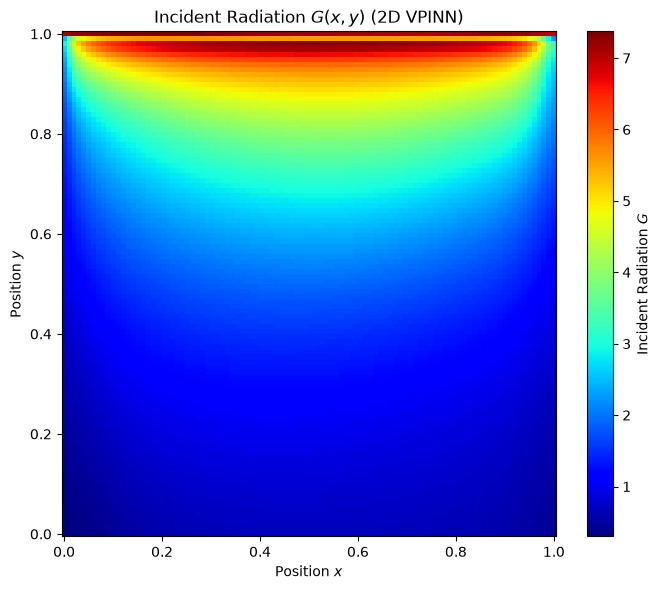

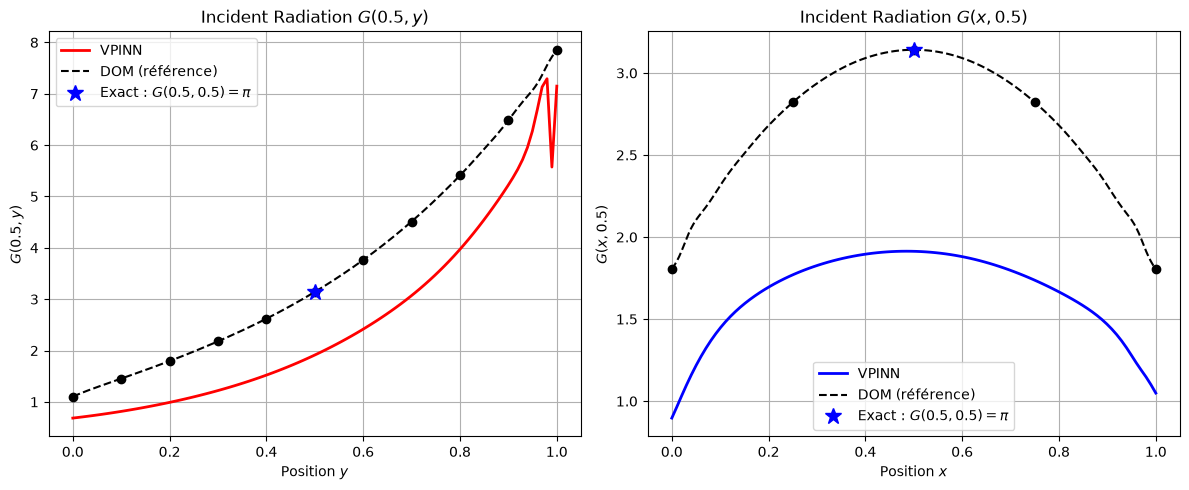

y            : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
G DOM        : [1.103 1.455 1.796 2.18  2.62  3.142 3.764 4.513 5.41  6.484 7.857]
G VPINN      : [0.685 0.815 0.991 1.221 1.522 1.913 2.417 3.071 3.972 5.226 7.149]
erreur rel.  : [37.9 43.9 44.8 44.  41.9 39.1 35.8 31.9 26.6 19.4  9. ] %


In [11]:
def evaluer_G(model, x_grid, y_grid, quad_mu, quad_eta, quad_w, device):
    Nx = len(x_grid)
    Ny = len(y_grid)
    X, Y = np.meshgrid(x_grid, y_grid)

    x_tensor = torch.tensor(X.ravel(), dtype=torch.float32).view(-1, 1).to(device)
    y_tensor = torch.tensor(Y.ravel(), dtype=torch.float32).view(-1, 1).to(device)

    with torch.no_grad():
        G_tensor = integrer_G(model, x_tensor, y_tensor, quad_mu, quad_eta, quad_w)

    return G_tensor.cpu().numpy().reshape(Y.shape)

x_vals = np.linspace(0.0, 1.0, 100)
y_vals = np.linspace(0.0, 1.0, 100)
G_pred = evaluer_G(modele, x_vals, y_vals, quad_mu, quad_eta, quad_w, device)

# Plot Heatmap of G(x, y)
fig, ax = plt.subplots(figsize=(7, 6))
X, Y = np.meshgrid(x_vals, y_vals)
im = ax.pcolormesh(X, Y, G_pred, cmap='jet', shading='auto')
ax.set_title("Incident Radiation $G(x, y)$ (2D VPINN)")
ax.set_xlabel("Position $x$")
ax.set_ylabel("Position $y$")
fig.colorbar(im, label="Incident Radiation $G$")
plt.tight_layout()
fig.savefig("intensity_heatmap_cas2_vpinn.png", dpi=150)
plt.show()

# Plot Line Profiles vs DOM reference
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ref_y = np.linspace(0.0, 1.0, 11)
ref_G_vertical = np.interp(ref_y, grid_dom, G_dom[mid_dom, :])

ref_x = np.linspace(0.0, 1.0, 5)
ref_G_horizontal = np.interp(ref_x, grid_dom, G_dom[:, mid_dom])

# Line x = 0.5
y_vals_line = np.linspace(0.0, 1.0, 100)
G_x05 = evaluer_G(modele, np.array([0.5]), y_vals_line, quad_mu, quad_eta, quad_w, device).flatten()
axes[0].plot(y_vals_line, G_x05, color='red', linewidth=2, label="VPINN")
axes[0].plot(grid_dom, G_dom[mid_dom, :], 'k--', linewidth=1.5, label="DOM (référence)")
axes[0].plot(ref_y, ref_G_vertical, 'ko')
axes[0].plot(0.5, np.pi, 'b*', markersize=12, label="Exact : $G(0.5, 0.5) = \\pi$")
axes[0].set_title("Incident Radiation $G(0.5, y)$")
axes[0].set_xlabel("Position $y$")
axes[0].set_ylabel("$G(0.5, y)$")
axes[0].grid(True)
axes[0].legend()

# Line y = 0.5
x_vals_line = np.linspace(0.0, 1.0, 100)
G_y05 = evaluer_G(modele, x_vals_line, np.array([0.5]), quad_mu, quad_eta, quad_w, device).flatten()
axes[1].plot(x_vals_line, G_y05, color='blue', linewidth=2, label="VPINN")
axes[1].plot(grid_dom, G_dom[:, mid_dom], 'k--', linewidth=1.5, label="DOM (référence)")
axes[1].plot(ref_x, ref_G_horizontal, 'ko')
axes[1].plot(0.5, np.pi, 'b*', markersize=12, label="Exact : $G(0.5, 0.5) = \\pi$")
axes[1].set_title("Incident Radiation $G(x, 0.5)$")
axes[1].set_xlabel("Position $x$")
axes[1].set_ylabel("$G(x, 0.5)$")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
fig.savefig("intensity_boundaries_cas2_vpinn.png", dpi=150)
plt.show()

# Erreur relative VPINN vs DOM sur la ligne verticale centrale
G_vpinn_at_ref = np.interp(ref_y, y_vals_line, G_x05)
err = np.abs(G_vpinn_at_ref - ref_G_vertical) / np.abs(ref_G_vertical)
print("y            :", np.round(ref_y, 2))
print("G DOM        :", np.round(ref_G_vertical, 3))
print("G VPINN      :", np.round(G_vpinn_at_ref, 3))
print("erreur rel.  :", np.round(100 * err, 1), "%")

## 11. Angular Distribution: Spheres of Directions


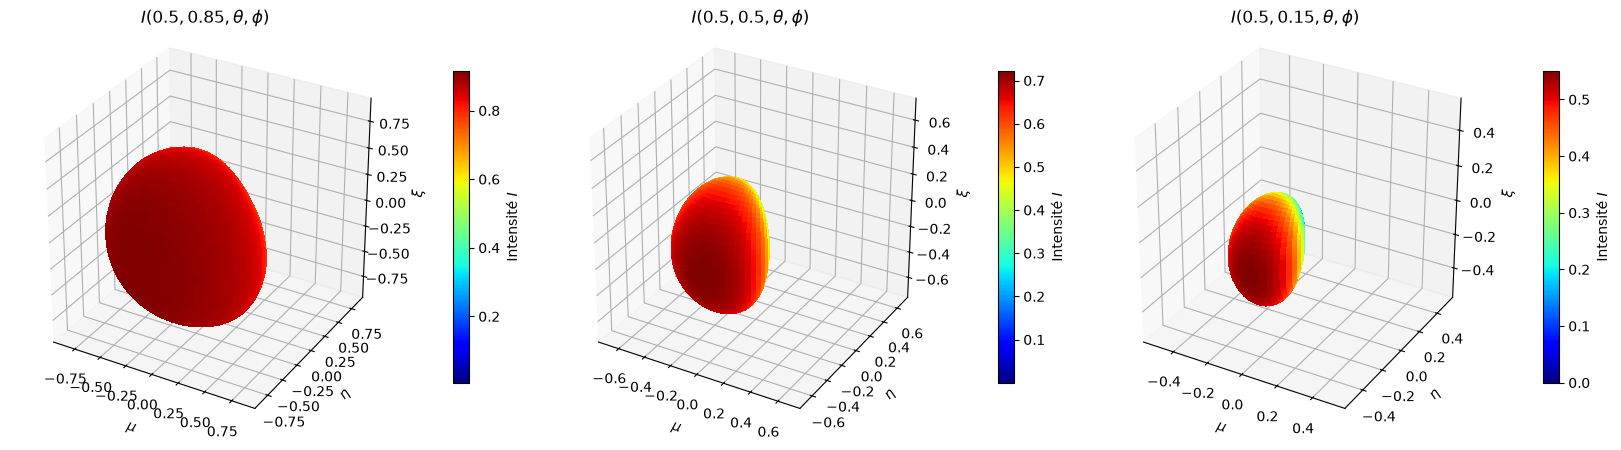

In [12]:
def tracer_spheres_intensite(model, points, device, n_theta=60, n_phi=121, deformer=True):
    theta = np.linspace(0.0, np.pi, n_theta)
    phi = np.linspace(0.0, 2.0 * np.pi, n_phi)
    TH, PH = np.meshgrid(theta, phi, indexing='ij')
    MU = np.sin(TH) * np.cos(PH)
    ETA = np.sin(TH) * np.sin(PH)
    XI = np.cos(TH)

    cmap = plt.get_cmap('jet')
    fig = plt.figure(figsize=(5.5 * len(points), 5.5))

    for k, (x0, y0) in enumerate(points):
        inp = np.stack([
            np.full(MU.size, x0),
            np.full(MU.size, y0),
            MU.ravel(),
            ETA.ravel(),
        ], axis=1)
        with torch.no_grad():
            I = model(torch.tensor(inp, dtype=torch.float32).to(device)).cpu().numpy().reshape(MU.shape)
        I = np.clip(I, 0.0, None)

        r = I if deformer else np.ones_like(I)
        norm = plt.Normalize(I.min(), I.max())

        ax = fig.add_subplot(1, len(points), k + 1, projection='3d')
        ax.plot_surface(r * MU, r * ETA, r * XI,
                        facecolors=cmap(norm(I)),
                        rstride=1, cstride=1, linewidth=0,
                        antialiased=False, shade=False)
        L = 1.05 * max(r.max(), 0.1)
        ax.set_xlim(-L, L); ax.set_ylim(-L, L); ax.set_zlim(-L, L)
        ax.set_box_aspect((1, 1, 1))
        ax.set_xlabel(r"$\mu$"); ax.set_ylabel(r"$\eta$"); ax.set_zlabel(r"$\xi$")
        ax.set_title(f"$I({x0}, {y0}, \\theta, \\phi)$")
        m = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        m.set_array(I)
        fig.colorbar(m, ax=ax, shrink=0.6, pad=0.1, label="Intensité $I$")

    plt.tight_layout()
    fig.savefig("intensity_spheres_cas2_vpinn.png", dpi=150)
    plt.show()

tracer_spheres_intensite(modele, [(0.5, 0.85), (0.5, 0.5), (0.5, 0.15)], device)